# Phase 4 – Model Training

This notebook trains a baseline Random Forest model for foul win probability prediction using the engineered dataset.

## 1 Introduction

This phase focuses on training a baseline classification model to estimate the probability that a player wins a foul after receiving or recovering the ball.

## 2 Objective

- Load the engineered dataset
- Select numeric features only
- Train a Random Forest baseline model
- Evaluate model accuracy and calibration metrics
- Save the trained model to disk

## 3 Imports

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root)
)

In [4]:

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.train_model import TrainModel


## 4 Load Engineered Dataset

In [5]:

data_path = Path("../data/processed/engineered_dataset.csv")

train_model = TrainModel(dataset_path=data_path)

dataset = train_model.load_dataset()
dataset.head()


2026-07-31 11:14:04 | INFO | Loading dataset from ..\data\processed\engineered_dataset.csv
2026-07-31 11:14:07 | INFO | Dataset loaded successfully (381267 rows × 57 columns)


,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,competition_id,match_id,target,x,y,distance_to_goal,goal_angle,pitch_zone,event_type,match_time_seconds
0,88200,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,6,1,00:00:00.898,0,0,2,NaN,b1c7e9af-19b2-47d8-855f-14aa3209648c,...,2,3753972,0,60.2,40.7,59.804097,-0.670656,Middle,0,0
1,88203,ec0b4585-41ad-4ada-817c-629d0866eeeb,9,1,00:00:01.808,0,1,2,NaN,"575d8b5a-1b10-4f34-98df-579cc0a52a2e, 70fc4868...",...,2,3753972,0,52.4,41.6,67.618932,-1.355860,Middle,0,1
2,88206,5244092d-6381-41a2-9ea8-727bc84aa5e6,12,1,00:00:04.502,0,4,2,NaN,3d440f32-9181-4e21-8d9d-f6993914f36c,...,2,3753972,0,33.2,60.9,89.280737,-13.538167,Defensive,0,4
3,88209,38650027-fd3b-42be-8fc3-d1a23c617665,15,1,00:00:06.655,0,6,2,NaN,234fa315-2c07-44f5-a31b-d993a98ce386,...,2,3753972,0,28.5,31.1,91.931823,5.555556,Defensive,0,6
4,88212,133fb108-6aff-45d7-8311-770dfc2d4810,18,1,00:00:10.480,0,10,2,NaN,f50a6695-4769-4c8b-a0cf-473df4d91dcf,...,2,3753972,0,26.8,60.2,95.363934,-12.229037,Defensive,0,10


## 5 Dataset Shape

The dataset shape is the starting point for feature selection and model training.

In [6]:
dataset.shape

(381267, 57)

## 6 Dataset Head

Inspect the first rows of the engineered dataset to confirm the expected feature and target columns.

In [7]:
dataset.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,competition_id,match_id,target,x,y,distance_to_goal,goal_angle,pitch_zone,event_type,match_time_seconds
0,88200,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,6,1,00:00:00.898,0,0,2,NaN,b1c7e9af-19b2-47d8-855f-14aa3209648c,...,2,3753972,0,60.2,40.7,59.804097,-0.670656,Middle,0,0
1,88203,ec0b4585-41ad-4ada-817c-629d0866eeeb,9,1,00:00:01.808,0,1,2,NaN,"575d8b5a-1b10-4f34-98df-579cc0a52a2e, 70fc4868...",...,2,3753972,0,52.4,41.6,67.618932,-1.355860,Middle,0,1
2,88206,5244092d-6381-41a2-9ea8-727bc84aa5e6,12,1,00:00:04.502,0,4,2,NaN,3d440f32-9181-4e21-8d9d-f6993914f36c,...,2,3753972,0,33.2,60.9,89.280737,-13.538167,Defensive,0,4
3,88209,38650027-fd3b-42be-8fc3-d1a23c617665,15,1,00:00:06.655,0,6,2,NaN,234fa315-2c07-44f5-a31b-d993a98ce386,...,2,3753972,0,28.5,31.1,91.931823,5.555556,Defensive,0,6
4,88212,133fb108-6aff-45d7-8311-770dfc2d4810,18,1,00:00:10.480,0,10,2,NaN,f50a6695-4769-4c8b-a0cf-473df4d91dcf,...,2,3753972,0,26.8,60.2,95.363934,-12.229037,Defensive,0,10


## 7 Dataset Info

Display the dataset schema and data types to verify numeric feature selection and the presence of the target variable.

In [8]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 381267 entries, 0 to 381266
Data columns (total 57 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 381267 non-null  int64  
 1   id                         381267 non-null  str    
 2   index                      381267 non-null  int64  
 3   period                     381267 non-null  int64  
 4   timestamp                  381267 non-null  str    
 5   minute                     381267 non-null  int64  
 6   second                     381267 non-null  int64  
 7   possession                 381267 non-null  int64  
 8   duration                   40943 non-null   float64
 9   related_events             360011 non-null  str    
 10  location                   381267 non-null  str    
 11  under_pressure             34829 non-null   object 
 12  counterpress               0 non-null       float64
 13  type.id                    381267 non-nu

## 8 Feature Selection

Select numeric features and exclude non-predictive identifiers and the target column.

In [9]:

X, y = train_model.prepare_data(dataset)

selected_features = list(X.columns)

print("Selected features:")
print(selected_features)
print(f"Number of features: {len(selected_features)}")


2026-07-31 11:14:22 | INFO | Preparing features and target variables...
2026-07-31 11:14:22 | INFO | Selected 40 numeric features for training.
2026-07-31 11:14:22 | INFO | Feature names: ['period', 'minute', 'second', 'possession', 'duration', 'counterpress', 'type.id', 'possession_team.id', 'play_pattern.id', 'team.id', 'tactics.formation', 'tactics.lineup', 'player.id', 'position.id', 'pass.length', 'pass.angle', 'pass.height.id', 'pass.height.name', 'pass.body_part.id', 'pass.body_part.name', 'pass.type.id', 'pass.type.name', 'pass.outcome.id', 'pass.outcome.name', 'pass.receipient.id', 'pass.recipient.name', 'pass.end_location', 'dribble.outcome.id', 'dribble.outcome.name', 'ball_receipt.outcome.id', 'carry.end_location', 'duel.outcome.id', 'duel.outcome.name', 'competition_id', 'x', 'y', 'distance_to_goal', 'goal_angle', 'event_type', 'match_time_seconds']
Selected features:
['period', 'minute', 'second', 'possession', 'duration', 'counterpress', 'type.id', 'possession_team.id', 

## 9 Train/Test Split

Split the data into training and testing subsets with stratified sampling to preserve class balance.

In [10]:

X_train, X_test, y_train, y_test = train_model.split_data(X, y)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")


2026-07-31 11:14:25 | INFO | Splitting data into train and test sets...
2026-07-31 11:14:26 | INFO | Training rows: 305013, Testing rows: 76254
Training rows: 305013
Testing rows: 76254


## 10 Train Random Forest Model

Train the baseline Random Forest classifier using the predefined model parameters.

In [11]:

model = train_model.train(X_train, y_train)

print(model)


2026-07-31 11:14:28 | INFO | Training Random Forest model...
2026-07-31 11:15:00 | INFO | Model training completed.
RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)


## 11 Predictions

Generate predicted labels and probabilities for the test set.

In [12]:

predictions = train_model.predict(model, X_test)

probabilities = train_model.predict_proba(model, X_test)

print("Predictions shape:", predictions.shape)
print("Probabilities shape:", probabilities.shape)


2026-07-31 11:15:43 | INFO | Generating predictions...
2026-07-31 11:15:43 | INFO | Generating prediction probabilities...
Predictions shape: (76254,)
Probabilities shape: (76254, 2)


## 12 Evaluation Metrics

Compute and display the model evaluation metrics for classification performance.

In [13]:

metrics = train_model.evaluate(y_test, predictions, probabilities)

print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1']:.4f}")
print(f"ROC AUC: {metrics['roc_auc']:.4f}")

print("Classification Report:")
print(metrics['classification_report'])

2026-07-31 11:15:46 | INFO | Evaluating model performance...
2026-07-31 11:15:46 | INFO | Evaluation metrics computed successfully.
Accuracy: 0.6601
Precision: 0.0421
Recall: 0.6402
F1 Score: 0.0790
ROC AUC: 0.7100
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     74517
           1       0.04      0.64      0.08      1737

    accuracy                           0.66     76254
   macro avg       0.51      0.65      0.44     76254
weighted avg       0.97      0.66      0.78     76254



## 13 Confusion Matrix

Plot the confusion matrix using matplotlib to visualize true versus predicted labels.

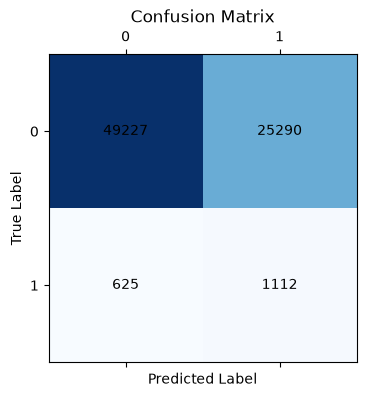

In [14]:

cm = metrics['confusion_matrix']

fig, ax = plt.subplots(figsize=(5, 4))
ax.matshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
plt.show()


## 14 ROC Curve

Plot the ROC curve using the predicted probabilities for the positive class.

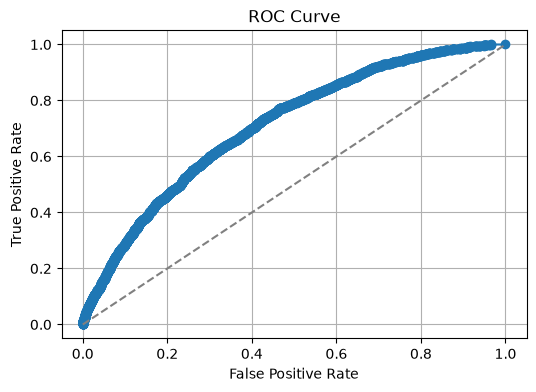

In [15]:

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, probabilities[:, 1])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, marker='o', linestyle='-')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.grid(True)
plt.show()


## 15 Feature Importance

Plot the top 20 feature importances from the trained Random Forest model.

2026-07-31 11:16:04 | INFO | Computing feature importance...
2026-07-31 11:16:04 | INFO | Feature importance computed.


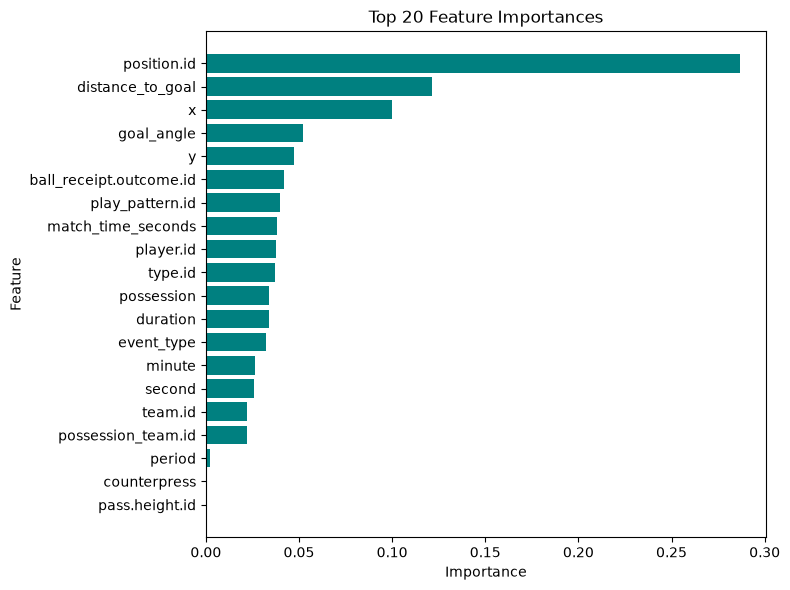

In [16]:

importance_df = train_model.feature_importance(model, selected_features)

top_features = importance_df.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_features['feature'][::-1], top_features['importance'][::-1], color='teal')
ax.set_title('Top 20 Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


## 16 Save Model

Save the trained model to the models directory and display the saved file location.

In [17]:

model_path = train_model.save_model(model)
print(f"Model saved to: {model_path}")


2026-07-31 11:16:10 | INFO | Saving model to C:\Users\91900\Teamwork_Online\epl-foul-prediction\models\random_forest_model.pkl
2026-07-31 11:16:10 | INFO | Model saved successfully.
Model saved to: C:\Users\91900\Teamwork_Online\epl-foul-prediction\models\random_forest_model.pkl


## 17 Summary & Insights

## 1. Objective Achieved

Phase 4 successfully trained a machine learning classifier to estimate EPL foul win probability using the engineered StatsBomb event dataset from Phase 3. The pipeline loaded the processed dataset, applied numeric feature selection, and used the target variable `target` to predict whether a foul win event occurs.

## 2. Dataset Summary

- Number of records used: 381,267
- Number of features used for training: 40 numeric features
- Train/Test split ratio: 80% training / 20% testing
- Random state: 42
- Target distribution: 97.72% negative class (no foul win) and 2.28% positive class (foul win)

The dataset is highly imbalanced, which means accuracy alone can be misleading. Class imbalance requires careful use of precision, recall, and ROC-AUC to evaluate whether the model is effectively identifying the minority foul-win events.

## 3. Model Selection - Why Random Forest?

RandomForestClassifier was selected because it is well suited to the EPL foul prediction problem:

- Handles nonlinear relationships between football event features
- Works well with structured tabular event data
- Captures feature interactions automatically without manual feature crossing
- Robust against noise and outliers present in event tracking data
- Requires less feature scaling than distance-based algorithms
- Provides feature importance for interpretability
- Performs well on classification tasks with mixed numeric feature behavior
- Supports class balancing through `class_weight="balanced"`

These strengths make Random Forest a strong first baseline for mapping event-level attributes to foul-win probability.

## 4. Why Not Other Models?

### Logistic Regression

- Good baseline model
- Assumes linear relationships
- May struggle because football events involve complex nonlinear interactions

### Decision Tree

- Easy to interpret
- But prone to overfitting compared with ensemble methods

### Support Vector Machine

- Computationally expensive on large datasets
- Less practical for hundreds of thousands of event records

### K-Nearest Neighbors

- Sensitive to feature scaling
- Prediction becomes expensive with large datasets

### Gradient Boosting / XGBoost

- Could potentially improve performance
- But Random Forest is a stronger first production baseline due to stability, interpretability, and reduced tuning complexity

### Neural Networks / Deep Learning

- Requires larger tuning effort
- More suitable for unstructured data such as images or text
- The current dataset is structured event data where tree-based models already perform strongly

## 5. Training Configuration

Model: `RandomForestClassifier`

Parameters used:

- `n_estimators`: 200
- `max_depth`: 10
- `class_weight`: "balanced"
- `random_state`: 42
- `n_jobs`: -1

## 6. Model Performance

Metric | Score
--- | ---
Accuracy | 0.6601
Precision | 0.0421
Recall | 0.6402
F1-score | 0.0790
ROC-AUC | 0.7100

- Accuracy alone is not sufficient because foul-win events are heavily imbalanced.
- Precision and recall provide better insight into the minority class prediction quality.
- ROC-AUC measures how well the model ranks positive events across classification thresholds.

## 7. Feature Importance Insights

Top features from the Random Forest model include:

- `position.id`
- `distance_to_goal`
- `x`
- `goal_angle`
- `y`
- `player.id`
- `match_time_seconds`
- `possession`
- `play_pattern.id`
- `type.id`

These important variables reflect football-specific signal such as spatial positioning, distance from goal, event location, match timing, and possession context.

## 8. Model Limitations

- Class imbalance may affect prediction quality for the positive foul-win class
- Only event-level numeric features are currently used
- Player and team contextual information is limited in this baseline
- Hyperparameter tuning has not been performed
- Probability calibration may improve prediction reliability

## 9. Next Steps (Phase 5)

- Perform advanced model evaluation with ROC curve analysis
- Add precision-recall curve analysis
- Tune classification threshold for the target objective
- Evaluate probability calibration
- Conduct error analysis on false positives and false negatives
- Compare against alternative model families
- Perform hyperparameter optimization
- Add explainability analysis with SHAP if required

## 10. Final Outcome

The Phase 4 pipeline successfully produced a trained Random Forest classification model capable of estimating foul-win probability from EPL event data. The trained model and artifacts are ready for Phase 5 evaluation and further optimization.